# 02 — Exploratory Analysis, Drift and Leakage Control

Analyze the training partition, measure random and temporal drift, then materialize leakage-safe train and test datasets.

## 1. Configuration and split loading

This notebook expects the train/test files produced by notebook `01`. Target-based EDA uses train only; test is read solely for drift measurement and leakage-safe materialization.

In [1]:
from bnpl_credit_risk.data.drift import DataDriftReport
from bnpl_credit_risk.data.loaders import BNPLDataLoader
from bnpl_credit_risk.settings import get_settings, load_config
from bnpl_credit_risk.visualization import BNPLLeakageAnalysis

settings = get_settings()
config = load_config()
leakage_analysis = BNPLLeakageAnalysis(
    target_column=config.data.target_column,
    numeric_columns=config.data.numeric_columns,
    size=config.data.exploratory_analysis.visualization.size,
)
drift_analysis = DataDriftReport(
    numeric_columns=tuple(config.data.numeric_columns),
    categorical_columns=tuple(config.data.categorical_columns),
    target_column=config.data.target_column,
    date_column=config.data.date_column,
    warning_psi=config.data.drift.warning_psi,
    critical_psi=config.data.drift.critical_psi,
)

split_directory = settings.resolve(config.data_split.output.directory)
train_path = split_directory / config.data_split.output.train_filename
test_path = split_directory / config.data_split.output.test_filename
missing_files = [path for path in (train_path, test_path) if not path.exists()]
if missing_files:
    missing = ", ".join(str(path) for path in missing_files)
    raise FileNotFoundError(
        f"Missing split file(s): {missing}. "
        "Run notebook 01_data_validation.ipynb completely first."
    )

loader = BNPLDataLoader(settings, config.data)
train_df = loader.load_raw(train_path)
test_df = loader.load_raw(test_path)
df = train_df
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

2026-08-27 20:29:20.555 | INFO     | bnpl_credit_risk.data.loaders:load_raw:37 - Loaded raw dataset path=/Users/surelmanda/3-Mlops-Databricks-Projects/BNPL-Credit-Risk/data/raw/train.csv rows=9310 columns=17
2026-08-27 20:29:20.559 | INFO     | bnpl_credit_risk.data.loaders:load_raw:37 - Loaded raw dataset path=/Users/surelmanda/3-Mlops-Databricks-Projects/BNPL-Credit-Risk/data/raw/test.csv rows=1035 columns=17


Train shape: (9310, 17)
Test shape: (1035, 17)


## 2. Target distribution

Check class balance on train before analyzing suspicious relationships with the target.

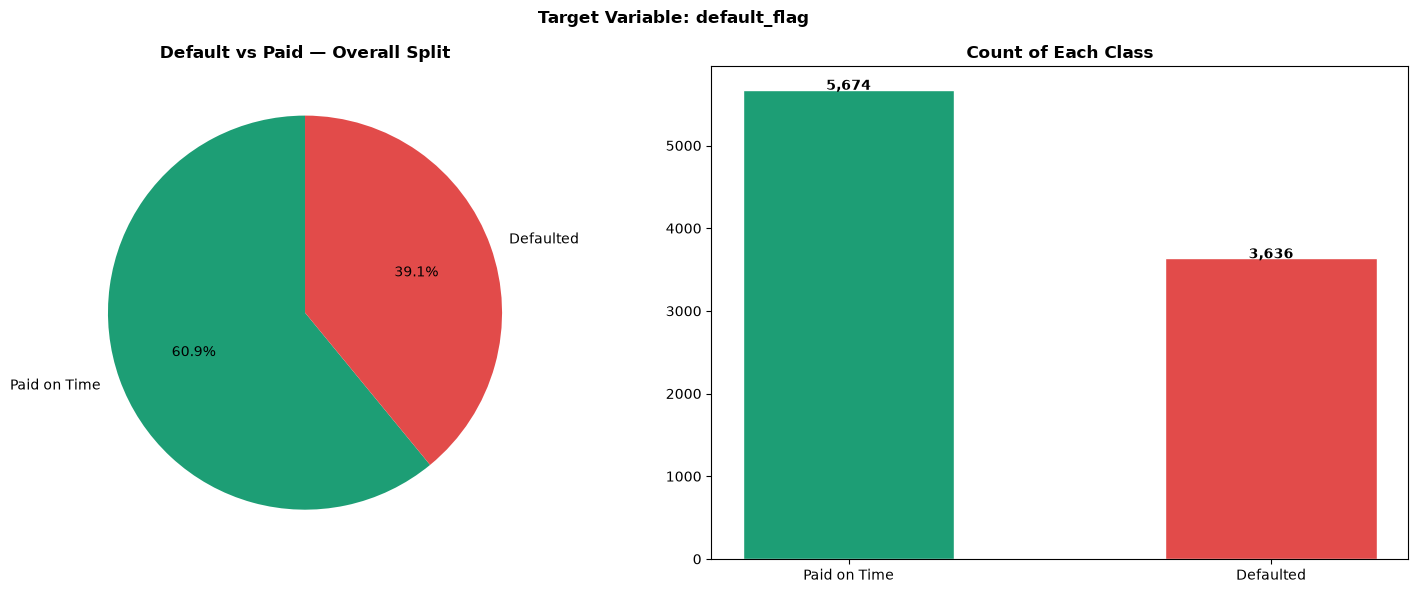

In [2]:
leakage_analysis.show_target_distribution(df)

## 3. Correlation screening

Correlation is only a warning signal. It does not establish leakage without temporal and business context.

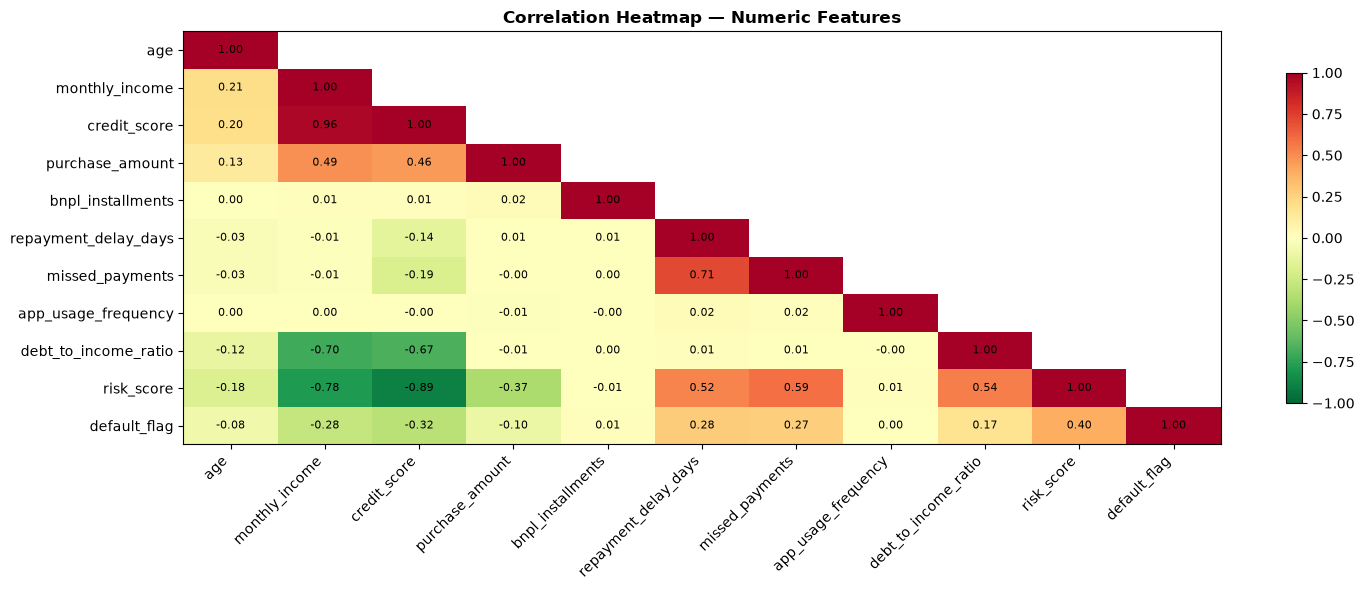

In [3]:
leakage_analysis.show_correlation(df)

## 4. Random-partition drift

Train is the reference. PSI measures distribution movement, KS measures numeric separation and `unseen_category_rate` detects categories present only in test. The target is included to detect label drift.

In [4]:
random_drift_report = drift_analysis.build(train_df, test_df)
display(random_drift_report.round(4))
print("Drift status counts:")
display(random_drift_report["status"].value_counts().rename_axis("status").to_frame("features"))

,feature,type,psi,ks_statistic,unseen_category_rate,reference_missing_rate,current_missing_rate,status
0,app_usage_frequency,numeric,0.0107,0.0201,0.0,0.0,0.0,stable
1,debt_to_income_ratio,numeric,0.0085,0.0264,0.0,0.0,0.0,stable
2,repayment_delay_days,numeric,0.0084,0.0269,0.0,0.0,0.0,stable
3,credit_score,numeric,0.0063,0.0226,0.0,0.0,0.0,stable
4,location,categorical,0.0056,NaN,0.0,0.0,0.0,stable
5,age,numeric,0.0055,0.0198,0.0,0.0,0.0,stable
6,monthly_income,numeric,0.0051,0.0237,0.0,0.0,0.0,stable
7,risk_score,numeric,0.0037,0.0184,0.0,0.0,0.0,stable
8,bnpl_installments,numeric,0.0023,0.0313,0.0,0.0,0.0,stable
9,product_category,categorical,0.0022,NaN,0.0,0.0,0.0,stable


Drift status counts:


,features
status,
stable,15


## 5. Chronological stability

The oldest training rows define the reference window. The most recent configured fraction is compared with it. Large drift in calendar-derived features must be interpreted separately from drift in customer or credit variables.

In [5]:
temporal_drift = drift_analysis.build_temporal(
    train_df,
    recent_fraction=config.data.drift.recent_fraction,
)
print(
    f"Reference window: {temporal_drift.reference[config.data.date_column].min().date()} "
    f"→ {temporal_drift.reference_end.date()} ({len(temporal_drift.reference):,} rows)"
)
print(
    f"Recent window: {temporal_drift.current_start.date()} "
    f"→ {temporal_drift.current[config.data.date_column].max().date()} "
    f"({len(temporal_drift.current):,} rows)"
)
display(temporal_drift.report.round(4))

Reference window: 2023-01-01 → 2024-10-19 (7,448 rows)
Recent window: 2024-10-19 → 2024-12-31 (1,862 rows)


,feature,type,psi,ks_statistic,unseen_category_rate,reference_missing_rate,current_missing_rate,status
0,purchase_amount,numeric,0.0133,0.0474,0.0,0.0,0.0,stable
1,debt_to_income_ratio,numeric,0.0104,0.0311,0.0,0.0,0.0,stable
2,employment_type,categorical,0.0083,NaN,0.0,0.0,0.0,stable
3,app_usage_frequency,numeric,0.0082,0.0209,0.0,0.0,0.0,stable
4,monthly_income,numeric,0.0078,0.0363,0.0,0.0,0.0,stable
5,repayment_delay_days,numeric,0.0069,0.0141,0.0,0.0,0.0,stable
6,credit_score,numeric,0.0066,0.0360,0.0,0.0,0.0,stable
7,age,numeric,0.0056,0.0181,0.0,0.0,0.0,stable
8,product_category,categorical,0.0054,NaN,0.0,0.0,0.0,stable
9,risk_score,numeric,0.0044,0.0209,0.0,0.0,0.0,stable


## 6. Semantic leakage assessment

The prediction is made at checkout. `repayment_delay_days` and `missed_payments` describe later repayment behavior. `risk_score` has undocumented provenance and behaves as a target proxy; `customer_segment` derives from that score. These columns remain excluded until pre-checkout availability is demonstrated.

## 7. Leakage control and safe datasets

Apply the semantic policy consistently to both partitions and materialize leakage-safe copies in `data/interim`.

In [6]:
from bnpl_credit_risk.pipelines.leakage_pipeline import LeakageControlPipeline

leakage_pipeline = LeakageControlPipeline(settings=settings, config=config)
leakage_result = leakage_pipeline.run(train_df, test_df)
display(leakage_result.report)
print(f"Removed columns: {list(leakage_result.removed_columns)}")
print(f"Clean train shape: {leakage_result.train.shape}")
print(f"Clean test shape: {leakage_result.test.shape}")
print(f"Clean train path: {leakage_result.paths.train_path}")
print(f"Clean test path: {leakage_result.paths.test_path}")

2026-08-27 20:29:22.543 | INFO     | bnpl_credit_risk.data.partitioning:save_train_test_csv:119 - Saved dataset partitions train=/Users/surelmanda/3-Mlops-Databricks-Projects/BNPL-Credit-Risk/data/interim/train_application.csv test=/Users/surelmanda/3-Mlops-Databricks-Projects/BNPL-Credit-Risk/data/interim/test_application.csv


,Column,Present,Availability,Leakage reason,Decision
0,repayment_delay_days,True,Post-origination / unproven at checkout,Available only after repayments have started.,Remove
1,missed_payments,True,Post-origination / unproven at checkout,Observed only after one or more scheduled repa...,Remove
2,risk_score,True,Post-origination / unproven at checkout,Provenance is undocumented and it behaves as a...,Remove
3,customer_segment,True,Post-origination / unproven at checkout,Derived from risk_score and therefore inherits...,Remove


Removed columns: ['repayment_delay_days', 'missed_payments', 'risk_score', 'customer_segment']
Clean train shape: (9310, 13)
Clean test shape: (1035, 13)
Clean train path: /Users/surelmanda/3-Mlops-Databricks-Projects/BNPL-Credit-Risk/data/interim/train_application.csv
Clean test path: /Users/surelmanda/3-Mlops-Databricks-Projects/BNPL-Credit-Risk/data/interim/test_application.csv


### Output for the next step

Notebook `03` consumes both leakage-safe files generated above.